# Exercicio 4

## Parte 1 – Regra de Associação

In [3]:
!pip install gensim
!pip install numpy
!pip install pandas
!pip install nltk

In [4]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/supermercado.csv", header=None, sep='\0', names=['items'])
df['items'] = df['items'].fillna('').apply(lambda x: list(set([c.strip() for c in x.split(',')])))
df

,items
0,"[semi-finished bread, citrus fruit, ready soup..."
1,"[yogurt, tropical fruit, coffee]"
2,[whole milk]
3,"[pip fruit, meat spreads, yogurt, cream cheese]"
4,"[other vegetables, condensed milk, whole milk,..."
...,...
9830,"[napkins, salty snack, whole milk, chicken, wh..."
9831,[cooking chocolate]
9832,"[rolls/buns, frozen dessert, chicken, domestic..."
9833,"[semi-finished bread, soda, bottled beer, bott..."


In [6]:
te = TransactionEncoder()
encoded = te.fit(df["items"]).transform(df["items"])
print(encoded)

df_items = pd.DataFrame(encoded, columns=te.columns_)
df_items

[[False False False ... False False False]
 [False False False ... False  True False]
 [False False False ...  True False False]
 ...
 [False False False ... False  True False]
 [False False False ... False False False]
 [False False False ... False False False]]


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9833,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
frequent_itemsets = apriori(df_items, min_support=0.001, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.008033,(Instant food products)
1,0.033452,(UHT-milk)
2,0.003559,(abrasive cleaner)
3,0.003254,(artif. sweetener)
4,0.017692,(baking powder)
...,...,...
13487,0.001017,"(whole milk, whipped/sour cream, citrus fruit,..."
13488,0.001017,"(whole milk, tropical fruit, yogurt, other veg..."
13489,0.001322,"(whole milk, tropical fruit, pip fruit, yogurt..."
13490,0.001322,"(rolls/buns, whole milk, tropical fruit, yogur..."


In [81]:
df_regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.25)
mask = df_regras['consequents'].apply(lambda cons: 'bottled beer' in cons)
df_regras[mask].sort_values(by="confidence", ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1105,"(red/blush wine, liquor)",(bottled beer),0.002135,0.080529,0.001932,0.904762,11.235269,1.0,0.001760,9.654448,0.912944,0.023929,0.896421,0.464376
1107,"(liquor, soda)",(bottled beer),0.002135,0.080529,0.001220,0.571429,7.095960,1.0,0.001048,2.145433,0.860913,0.014981,0.533894,0.293290
27,(liquor),(bottled beer),0.011083,0.080529,0.004677,0.422018,5.240594,1.0,0.003785,1.590831,0.818250,0.053801,0.371398,0.240050
1016,"(herbs, bottled water)",(bottled beer),0.003050,0.080529,0.001220,0.400000,4.967172,1.0,0.000974,1.532452,0.801122,0.014815,0.347451,0.207576
1178,"(soups, whole milk)",(bottled beer),0.002949,0.080529,0.001118,0.379310,4.710249,1.0,0.000881,1.481370,0.790027,0.013580,0.324949,0.196600
1156,"(red/blush wine, soda)",(bottled beer),0.004575,0.080529,0.001627,0.355556,4.415264,1.0,0.001258,1.426766,0.777068,0.019488,0.299114,0.187879
1126,"(other vegetables, red/blush wine)",(bottled beer),0.004982,0.080529,0.001525,0.306122,3.801407,1.0,0.001124,1.325120,0.740629,0.018160,0.245352,0.162531
7875,"(other vegetables, domestic eggs, bottled water)",(bottled beer),0.004067,0.080529,0.001220,0.300000,3.725379,1.0,0.000893,1.313530,0.734558,0.014634,0.238693,0.157576
1021,"(oil, bottled water)",(bottled beer),0.004169,0.080529,0.001220,0.292683,3.634516,1.0,0.000884,1.299942,0.727895,0.014616,0.230735,0.153917
29,(tea),(bottled beer),0.003864,0.080529,0.001118,0.289474,3.594664,1.0,0.000807,1.294071,0.724610,0.013431,0.227245,0.151681


Avaliação: a maior parte dos antecedentes contém pelo menos um tipo de bebida, como "bottled water" e "soda", além disso, as associações com mais confiança, são alcoólicas, como "liquor", "red/blush wine". 

# Parte 2 – Mineração de texto

## 2.a - Tópicos

In [30]:
import nltk
import numpy as np
import string
import re
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from gensim.models.ldamodel import LdaModel
from gensim.corpora.dictionary import Dictionary
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /Users/pedro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/pedro/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/pedro/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [32]:
PONTUACAO = string.punctuation

def remove_pontuacao(text):
    return text.translate(str.maketrans('', '', PONTUACAO))

STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

url_pattern = re.compile(r'https?://\S+|www\.\S+')

def remove_urls(text):
    return url_pattern.sub("", text)


def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

In [47]:
df_trump = pd.read_csv("../data/tweets_trump.csv")
df_trump

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f
...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,RT @RandPaul: I don’t know why @JoeBiden think...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f
56567,1319484210101379072,RT @EliseStefanik: President @realDonaldTrump ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f
56568,1319444420861829121,RT @TeamTrump: LIVE: Presidential Debate #Deba...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f
56569,1319384118849949702,Just signed an order to support the workers of...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f


In [48]:
df_trump["text"] = df_trump["text"].str.lower()
df_trump["text"] = df_trump["text"].apply(remove_urls)
df_trump["text"] = df_trump["text"].apply(remove_pontuacao)
df_trump["text"] = df_trump["text"].apply(remove_stopwords)
df_trump["text"] = df_trump["text"].apply(stem_words)

In [49]:
df_trump["text"]

0                 republican democrat creat econom problem
1        thrill back great citi charlott north carolina...
2        rt cbsherridg read letter surveil court obtain...
3        unsolicit mail ballot scam major threat democr...
4        rt mzhemingway friendli tell event comey appar...
                               ...                        
56566    rt randpaul don’t know joebiden think continu ...
56567    rt elisestefanik presid realdonaldtrump excel ...
56568    rt teamtrump live presidenti debat debates2020...
56569    sign order support worker delphi corpor make s...
56570    suburban women want safeti amp secur joe biden...
Name: text, Length: 56571, dtype: object

In [37]:
dataset = [d.split() for d in df_trump["text"]]
dictionary = Dictionary(dataset)
corpus =  [dictionary.doc2bow(doc) for doc in dataset]

model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, iterations=100, passes=5, random_state=42)

In [40]:
for i in model.show_topics(num_topics=5, num_words=6, log=False):
   print(i)
   print("===================")

(0, '0.073*"rt" + 0.056*"realdonaldtrump" + 0.042*"trump" + 0.034*"presid" + 0.009*"vote" + 0.009*"donald"')
(1, '0.021*"border" + 0.016*"amp" + 0.015*"rt" + 0.011*"us" + 0.011*"wall" + 0.010*"american"')
(2, '0.012*"democrat" + 0.011*"amp" + 0.010*"peopl" + 0.009*"news" + 0.008*"never" + 0.008*"time"')
(3, '0.016*"hunt" + 0.016*"witch" + 0.015*"hous" + 0.014*"white" + 0.009*"amaz" + 0.008*"pm"')
(4, '0.081*"great" + 0.045*"thank" + 0.015*"america" + 0.013*"hillari" + 0.013*"job" + 0.012*"make"')


##  2.b - Avaliação dos tópicos
Remover stopwords específicas para tweets e nomes de perfis pode gerar resultados melhores. Os principais exemplos são as palavras "RT" e "realdonaldtrump".

In [52]:
sent = SentimentIntensityAnalyzer()

def verifica_positivo(review):
    return sent.polarity_scores(review)["compound"] > 0.8

In [50]:
top_tweets = df_trump.sort_values(ascending=False, by="retweets").head(5)
top_tweets

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
11759,1311892190680014849,tonight flotu test posit covid19 begin quarant...,f,f,Twitter for iPhone,1869706,408866,2020-10-02 04:54:06,f
35620,881503147168071680,fraudnewscnn fnn,f,f,Twitter for iPhone,503063,293109,2017-07-02 13:21:42,f
39347,795954831718498305,today make america great,f,f,Twitter for Android,498035,281289,2016-11-08 11:43:14,f
29598,474134260149157888,allow impeach presid gross incompet,f,f,Twitter for Android,231077,237674,2014-06-04 10:23:11,f
9080,1267637602724839424,rt spacex liftoff,t,f,Twitter for iPhone,0,235250,2020-06-02 02:02:10,f


## 3.a - Sentimento dos 5 tweets com mais retweets
Dentre os 5 tweets mais retweetados, 3 são neutros, um é positivo e outro negativo.

In [55]:
for tweet in top_tweets["text"]:
    print(tweet, sent.polarity_scores(tweet))
    print("===================")

tonight flotu test posit covid19 begin quarantin recoveri process immedi get togeth {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
fraudnewscnn fnn {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
today make america great {'neg': 0.0, 'neu': 0.423, 'pos': 0.577, 'compound': 0.6249}
allow impeach presid gross incompet {'neg': 0.388, 'neu': 0.375, 'pos': 0.237, 'compound': -0.296}
rt spacex liftoff {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


In [67]:
df_trump["compound_polarity"] = df_trump["text"].apply(lambda row: float(sent.polarity_scores(row)["compound"]))
df_trump

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,polarity,compound_polarity
0,98454970654916608,republican democrat creat econom problem,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,-0.4019,-0.4019
1,1234653427789070336,thrill back great citi charlott north carolina...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,0.9584,0.9584
2,1218010753434820614,rt cbsherridg read letter surveil court obtain...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,0.0000,0.0000
3,1304875170860015617,unsolicit mail ballot scam major threat democr...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,-0.9042,-0.9042
4,1218159531554897920,rt mzhemingway friendli tell event comey appar...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,-0.3400,-0.3400
...,...,...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,rt randpaul don’t know joebiden think continu ...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f,-0.5106,-0.5106
56567,1319484210101379072,rt elisestefanik presid realdonaldtrump excel ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f,0.4588,0.4588
56568,1319444420861829121,rt teamtrump live presidenti debat debates2020...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f,0.0000,0.0000
56569,1319384118849949702,sign order support worker delphi corpor make s...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f,-0.1027,-0.1027


## 3.b - Sentimento geral dos tweets

Quase metade dos tweets são, pelo menos, minimamente positivos, sendo 49% do total, enquanto 22% são negativos e o restante, 28%, neutros.

In [83]:
def polarity_cat(compound):
    if compound > 0:
        return "positive"
    if compound < 0:
        return "negative"
    return "neutral"

df_trump["polarity"] = df_trump["compound_polarity"].apply(polarity_cat)
print(df_trump["polarity"].value_counts())
df_trump['polarity'].value_counts(normalize=True).mul(100).astype(str)+'%'

polarity
positive    27890
neutral     16111
negative    12570
Name: count, dtype: int64


polarity
positive     49.30087854200916%
neutral      28.47925615598098%
negative    22.219865302009865%
Name: proportion, dtype: object

([<matplotlib.patches.Wedge at 0x31bc36f60>,
 [Text(0.024157936684917315, 1.09973469259414, 'positive'),
  Text(-0.7253406106270538, -0.8269709780730958, 'neutral'),
  Text(0.8427013120990771, -0.7070038886643368, 'negative')],
 [Text(0.013177056373591262, 0.5998552868695309, '49.3%'),
  Text(-0.3956403330693021, -0.4510750789489613, '28.5%'),
  Text(0.4596552611449511, -0.3856384847260019, '22.2%')])

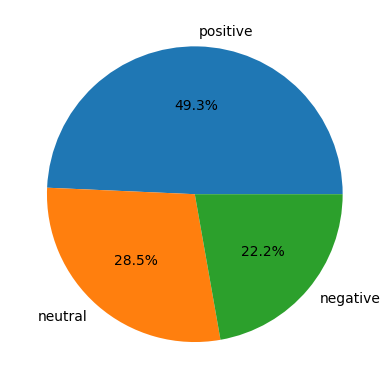

In [91]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.pie(df_trump["polarity"].value_counts(), labels=["positive", "neutral", "negative"], autopct='%1.1f%%')